# Laboratory 1: Communication System & Signal Flow

Martin Demel

Department of Science, Technology, Engineering & Math, Houston Community College

6263-ITAI-4370-AI 5/6G Comm & ORAN Net-S10-14071

Tawanda Chiyangwa
June 8th, 2026.


In this lab I model a digital communication system and analyze how a signal flows through it. A digital message travels through five blocks — **Source → Modulator → Channel → Demodulator → Receiver**. In Part 1 I draw this as a block diagram, and in Part 2 I simulate the full signal flow in Python using BPSK modulation over a noisy channel.

## Part 1: Conceptual Block Diagram

I model the communication system as five functional blocks connected left to right, with noise entering at the channel. The **Source** produces the information bits, the **Modulator** maps them onto a carrier using BPSK, the **Channel** adds noise, and the **Demodulator** and **Receiver** recover the original bits. The block diagram below shows this signal path.

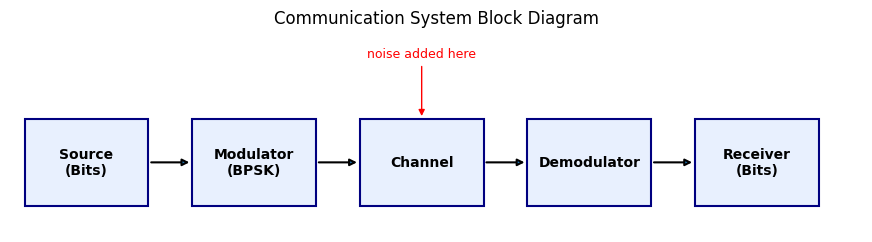

In [1]:
import matplotlib.pyplot as plt

blocks = ["Source\n(Bits)", "Modulator\n(BPSK)", "Channel", "Demodulator", "Receiver\n(Bits)"]

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis("off")
x = 0
for i, name in enumerate(blocks):
    ax.add_patch(plt.Rectangle((x, 0), 1.7, 1, facecolor="#e8f0fe", edgecolor="navy", lw=1.5))
    ax.text(x + 0.85, 0.5, name, ha="center", va="center", fontweight="bold")
    if i < len(blocks) - 1:                       # arrow to the next block
        ax.annotate("", xy=(x + 2.3, 0.5), xytext=(x + 1.7, 0.5),
                    arrowprops=dict(arrowstyle="-|>", lw=1.5))
    x += 2.3


ax.annotate("noise added here", xy=(5.45, 1.0), xytext=(5.45, 1.7),
            ha="center", color="red", fontsize=9,
            arrowprops=dict(arrowstyle="-|>", color="red"))

ax.set_xlim(-0.2, x); ax.set_ylim(-0.3, 2.0)
ax.set_title("Communication System Block Diagram")
plt.show()

## Part 2: Signal Flow in Python

To see what happens to the signal at each stage, I send 8 random bits through the chain. I map the bits to BPSK symbols (0 → −1, 1 → +1) on a cosine carrier, add Gaussian noise in the channel, and then demodulate and recover the bits.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
N, sps, fc = 8, 50, 2 
t = np.arange(0, N, 1/sps)

# 1. Source: random bits
bits = np.random.randint(0, 2, N)

# 2. Modulator (BPSK)
baseband = np.repeat(2*bits - 1, sps)
carrier  = np.cos(2*np.pi*fc*t)
tx = baseband * carrier

# 3. Channel: add noise
rx = tx + 0.5*np.random.randn(len(tx))

# 4. Demodulator: multiply by carrier, average over each bit
demod    = rx * carrier
decision = demod.reshape(N, sps).mean(axis=1)

# 5. Receiver: decide each bit
bits_out = (decision > 0).astype(int)

print("Sent bits:    ", bits)
print("Received bits:", bits_out)
print("Bit errors:   ", int(np.sum(bits != bits_out)))

Sent bits:     [0 1 0 0 0 1 0 0]
Received bits: [0 1 0 0 0 1 0 0]
Bit errors:    0


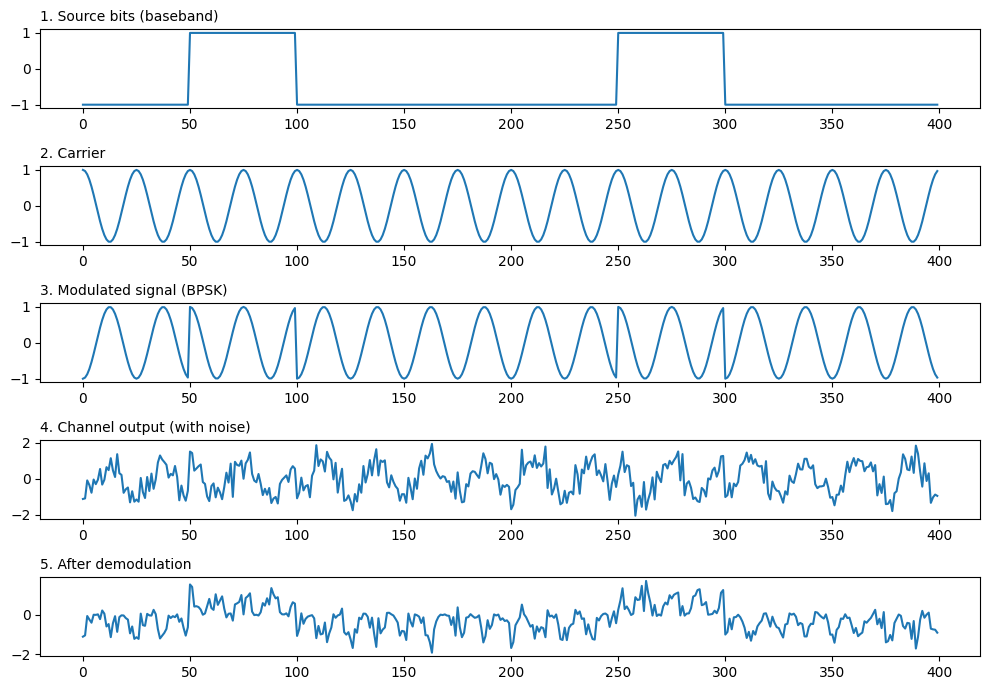

In [3]:
# Plot the signal at each stage of the chain
signals = [(baseband, "1. Source bits (baseband)"),
           (carrier,  "2. Carrier"),
           (tx,       "3. Modulated signal (BPSK)"),
           (rx,       "4. Channel output (with noise)"),
           (demod,    "5. After demodulation")]

plt.figure(figsize=(10, 7))
for i, (sig, title) in enumerate(signals):
    plt.subplot(5, 1, i + 1)
    plt.plot(sig)
    plt.title(title, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## Summary

The plots show how the signal changes at each stage. The modulator turns the bits into a BPSK waveform whose phase flips whenever the bit changes. The channel adds noise, the only point where the signal is degraded. By multiplying the received signal by the carrier and averaging over each bit, I recover the original message, and in this run all eight bits come back with zero errors. Together the two parts trace the complete transmitter → channel → receiver path of a digital communication system.